# Optimal quoting vs. classical Avellaneda-Stoikov — a bolder vol view

`option_mm_vol_arbitrage.ipynb` benchmarks optimal quoting rule against
classical AS at a **mild** vol view (`σ = σ_imp + 5 points`) and finds
optimal wins by only a small margin. 

**This notebook reruns the identical comparison at a bold vol view (`σ = σ_imp + 30 points`)** —
same contract, same liquidity/inventory parameters, same simulation machinery, only the *belief*
changes. The realised volatility of the simulated
spot path itself is pinned to the mild notebook's `σ_imp + 5 points` throughout, so widening the
belief doesn't also widen the trading simulation: any change below is attributable to beliefs, not to a
mechanically more volatile simulation.

In [23]:
import os, sys
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../src/vol_surface'))

import json, warnings
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from option_market_making import bs_mm, riccati
from option_market_making.edge import phi_edge
from option_market_making.psi1 import flow_corrections, psi1
from option_market_making.quoting import MMParams, optimal_spreads
from option_market_making.benchmarks import calibrate_gamma, simulate_avellaneda_stoikov, symmetric_kappa
from option_market_making.sim import objective, objective_summary, simulate

%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#dcdcd8'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GRID, 'axes.labelcolor': MUTED,
    'axes.titlecolor': INK, 'axes.titlesize': 11, 'axes.titleweight': 'semibold',
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'grid.color': GRID, 'grid.linewidth': 0.6,
    'legend.frameon': False, 'lines.linewidth': 2.0,
})

## 1. The surface and the contract

Same frozen Deribit snapshot as `option_mm_vol_arbitrage.ipynb` — a real, live-calibrated Global
eSSVI surface.

In [24]:
SNAPSHOT = '../tests/option_market_making/deribit_snapshot.json'

from vol_surface.global_essvi import ESSVISlice, GlobalESSVISurface

snap = json.load(open(SNAPSHOT))
surface = GlobalESSVISurface(snap['maturities'], [ESSVISlice(**s) for s in snap['slices']], snap['forwards'])
S0, K, tau = snap['spot'], snap['strike'], snap['tau']

IV = bs_mm.sigma_imp(surface, K, tau)
O_0 = bs_mm.call_price(S0, K, tau, IV)

print(f"spot        S0    = {S0:,.0f}")
print(f"strike      K     = {K:,.0f}   ({K / S0 - 1:+.2%} moneyness)")
print(f"expiry      tau   = {tau:.4f} yr  ({tau * 365:.0f} calendar days)")
print(f"implied vol       = {IV:.2%}")
print(f"call mark   O(0)  = {O_0:,.0f}   ({O_0 / S0:.2%} of spot)")

spot        S0    = 79,420
strike      K     = 80,000   (+0.73% moneyness)
expiry      tau   = 0.0847 yr  (31 calendar days)
implied vol       = 40.75%
call mark   O(0)  = 3,485   (4.39% of spot)


## 2. Parameters — a bold vol view

Identical to `option_mm_vol_arbitrage.ipynb`'s own baseline **except for one number**: the maker's
volatility view is `σ_imp + 30 points`, not `+5`. Everything else — `α`, `β`, `λ₀ᵇ,λ₀ᵃ`, `κᵇ,κᵃ` — is
untouched.


In [25]:
PARAMS = MMParams(
    alpha=2.0, beta=4357.0,
    lambda0_b=252 * 100 * 1.15, lambda0_a=252 * 100.0,
    kappa_b=0.025, kappa_a=0.030,
    sigma=IV + 0.30,   # <-- the one number changed from option_mm_vol_arbitrage.ipynb's +0.05
)
T = 0.5 / 252

Q0 = 0.0
edge_0 = phi_edge(0.0, S0, K, tau, T, IV, PARAMS)
flow_0 = flow_corrections(0.0, T, PARAMS)
psi2_0 = riccati.psi2(0.0, T, PARAMS)
db_0, da_0 = optimal_spreads(0.0, S0, Q0, K, tau, T, IV, PARAMS)

anatomy = pd.DataFrame({
    'component':    ['liquidity', 'vol-arb edge', 'order-flow correction', 'inventory', 'TOTAL half-spread'],
    'bid formula':  ['1/κᵇ', '−φ(t,s)', '−[ψ₁−φ]',
                     '−(2q+1)ψ₂(t)', 'δᵇ,*(t,s,q)'],
    'bid ($)':      [1 / PARAMS.kappa_b, -edge_0, -flow_0, -(2 * Q0 + 1) * psi2_0, db_0],
    'ask formula':  ['1/κᵃ', '+φ(t,s)', '+[ψ₁−φ]',
                     '+(2q−1)ψ₂(t)', 'δᵃ,*(t,s,q)'],
    'ask ($)':      [1 / PARAMS.kappa_a, edge_0, flow_0, (2 * Q0 - 1) * psi2_0, da_0],
})
anatomy['share of bid'] = (anatomy['bid ($)'].abs() / db_0).map('{:.1%}'.format)
display(anatomy)
print(f"\nquoted width = {db_0 + da_0:,.2f}  ({(db_0 + da_0) / O_0 * 1e4:.0f} bp of the option mark)")
print(f"vol-arb edge phi = {edge_0:.2f}  ({edge_0/(1/PARAMS.kappa_b):.1%} of 1/kappa_b, "
      f"vs 6.5% at the mild +5-point view)")

,component,bid formula,bid ($),ask formula,ask ($),share of bid
0,liquidity,1/κᵇ,40.000,1/κᵃ,33.333,163.8%
1,vol-arb edge,"−φ(t,s)",-20.140,"+φ(t,s)",20.140,82.5%
2,order-flow correction,−[ψ₁−φ],2.561,+[ψ₁−φ],-2.561,10.5%
3,inventory,−(2q+1)ψ₂(t),2.000,+(2q−1)ψ₂(t),2.000,8.2%
4,TOTAL half-spread,"δᵇ,*(t,s,q)",24.421,"δᵃ,*(t,s,q)",52.912,100.0%



quoted width = 77.33  (222 bp of the option mark)
vol-arb edge phi = 20.14  (50.3% of 1/kappa_b, vs 6.5% at the mild +5-point view)


## 3. Classical Avellaneda-Stoikov (2008), and its own volatility

Exactly as in `option_mm_vol_arbitrage.ipynb`'s §8: `σ_O:=|Δ_t|S_t σ_imp`, `k` is the average of
`κᵇ,κᵃ`, and `γ` is calibrated by bisection to match AS's own simulated `mean|q|` to the optimal
rule's, so every comparison below is risk-matched. One addition here: `realised_sigma` is pinned
to the mild notebook's `σ_imp + 5 points` for every simulate call below (optimal, fixed-width, and
AS alike), so the simulated world is identical to the mild notebook's — only the belief encoded in
`PARAMS.sigma` differs.

In [26]:
N_PATHS, N_STEPS = 4000, 400
REALISED_SIGMA = IV + 0.05   # pin the simulated world to option_mm_vol_arbitrage.ipynb's mild view
SIM = dict(S0=S0, n_steps=N_STEPS, n_paths=N_PATHS, seed=42, realised_sigma=REALISED_SIGMA)
CAL = dict(S0=S0, n_steps=N_STEPS, n_paths=3000, seed=7, realised_sigma=REALISED_SIGMA)
BRACKET = (-7.0, -4.6)   # verified stable across vol gaps 5-40 points; re-check before reusing elsewhere

runs = {'optimal (eq. 11)': simulate(surface, K, tau, T, PARAMS, **SIM)}
runs['fixed-width x1'] = simulate(
    surface, K, tau, T, PARAMS, constant_spreads=(1/PARAMS.kappa_b, 1/PARAMS.kappa_a), **SIM,
)

target_mean_abs_q = float(np.abs(runs['optimal (eq. 11)'].q).mean())
print(f"realised sigma  = {REALISED_SIGMA:.2%}  (mild view, same for every strategy)")
print(f"k (symmetric)   = {symmetric_kappa(PARAMS):.4f}")
print(f"target mean|q|  = {target_mean_abs_q:.4f}  (optimal rule's own)")

gamma_star = calibrate_gamma(surface, K, tau, T, PARAMS, target_mean_abs_q,
                             log10_gamma_bracket=BRACKET, **CAL)
runs['classical AS (2008)'] = simulate_avellaneda_stoikov(surface, K, tau, T, PARAMS, gamma_star, **SIM)
print(f"calibrated gamma = {gamma_star:.4e}  "
      f"achieved mean|q|={np.abs(runs['classical AS (2008)'].q).mean():.4f}")

assert all(np.array_equal(runs['optimal (eq. 11)'].S, r.S) for r in runs.values()), \
    'paired comparison requires identical spot paths'

summary = pd.DataFrame([
    {'strategy': name, 'mean V_T': r.terminal_value.mean(), 'mean |q|': np.abs(r.q).mean(),
     'max |q|': np.abs(r.q).max(), 'fills / path': (r.n_bid_fills + r.n_ask_fills).mean()}
    for name, r in runs.items()
])
display(summary)

realised sigma  = 45.75%  (mild view, same for every strategy)
k (symmetric)   = 0.0275
target mean|q|  = 3.4706  (optimal rule's own)
calibrated gamma = 2.7098e-06  achieved mean|q|=3.4351


,strategy,mean V_T,mean |q|,max |q|,fills / path
0,optimal (eq. 11),"1,438.779",3.471,14.000,39.034
1,fixed-width x1,"1,482.779",3.489,31.000,39.618
2,classical AS (2008),"1,479.327",3.435,23.000,39.654


Notice the calibrated gamma here is	smaller thatn the mild notebook.

## 4. The objective comparison (eq. 2)


In [27]:
display(objective_summary(runs, PARAMS))

base = objective(runs['optimal (eq. 11)'], PARAMS)
paired = pd.DataFrame([
    {'vs': name,
     'objective gap': (d := base - objective(r, PARAMS)).mean(),
     '95% CI': 1.96 * d.std() / np.sqrt(N_PATHS),
     't-stat': d.mean() / (d.std() / np.sqrt(N_PATHS)),
     'optimal wins on': f'{100 * (d > 0).mean():.1f}% of paths'}
    for name, r in runs.items() if not name.startswith('optimal')
])
display(paired)

,strategy,mean V_T,running penalty/fee,terminal penalty/fee,OBJECTIVE (value after fees),objective sd
0,optimal (eq. 11),"1,438.779",143.720,24.791,"1,270.268",336.151
1,fixed-width x1,"1,482.779",191.233,93.010,"1,198.537",450.650
2,classical AS (2008),"1,479.327",181.867,101.385,"1,196.075",411.538


,vs,objective gap,95% CI,t-stat,optimal wins on
0,fixed-width x1,71.731,17.373,8.093,53.3% of paths
1,classical AS (2008),74.193,16.425,8.853,54.8% of paths


In [30]:
143.720	+ 24.791	

168.511

In [32]:
181.867	+ 101.385	

283.252

In [33]:
(68.562-47.073)/68.562

print(f"Optimal policy cuts the inventory-risk cost component by about {((283.252-168.511)/283.252)*100:.2f}% with closed P&L")

Optimal policy cuts the inventory-risk cost component by about 40.51% with closed P&L


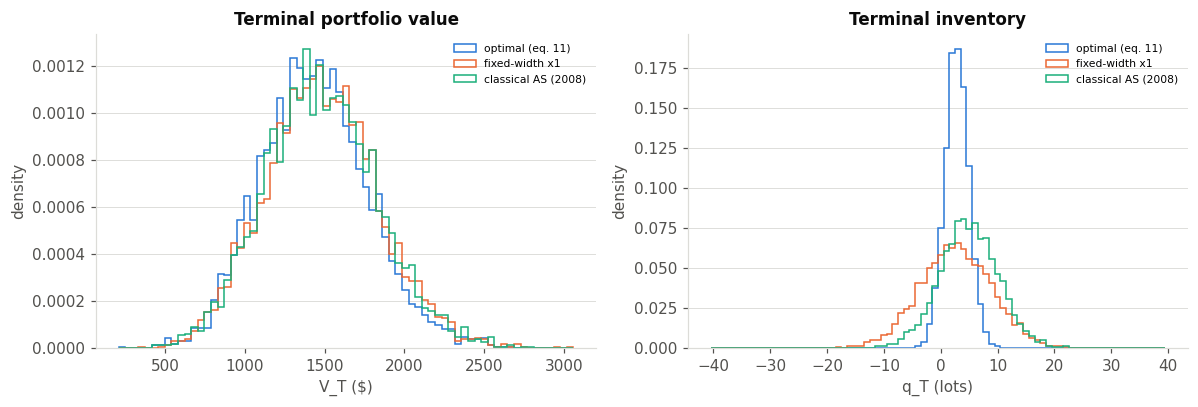

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.linspace(min(r.terminal_value.min() for r in runs.values()),
                   max(r.terminal_value.max() for r in runs.values()), 70)
for color, (name, r) in zip(SERIES, runs.items()):
    axes[0].hist(r.terminal_value, bins=bins, histtype='step', density=True, color=color, label=name)
    axes[1].hist(r.q[:, -1], bins=np.arange(-40, 41) - 0.5, histtype='step', density=True,
                 color=color, label=name)
axes[0].set_title('Terminal portfolio value'); axes[0].set_xlabel('V_T ($)'); axes[0].set_ylabel('density')
axes[1].set_title('Terminal inventory'); axes[1].set_xlabel('q_T (lots)'); axes[1].set_ylabel('density')
axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
for ax in axes:
    ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 5. How the gap scales with vol-views.


,vol view (pts),phi ($),phi as % of 1/kappa_b,objective gap,95% CI,t-stat
0,5,2.616,6.5%,24.012,15.040,3.129
1,10,5.529,13.8%,26.385,15.312,3.377
2,15,8.740,21.9%,34.714,14.745,4.614
3,20,12.247,30.6%,28.205,15.104,3.660
4,25,16.047,40.1%,48.999,15.434,6.222
5,30,20.140,50.3%,74.193,16.425,8.853


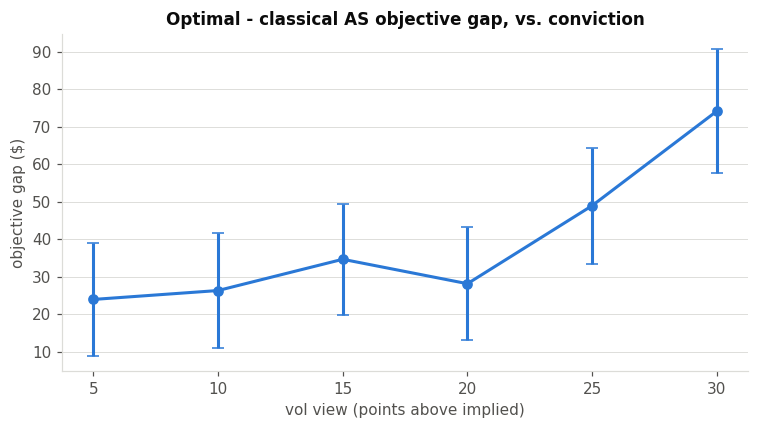

In [29]:
GAP_BRACKET = (-7.0, -4.6)   # verified stable across this whole sweep -- re-check if reusing elsewhere
gaps_to_test = (0.05, 0.10, 0.15, 0.20, 0.25, 0.30)

sweep_rows = []
for g in gaps_to_test:
    p = replace(PARAMS, sigma=IV + g)
    phi_here = phi_edge(0.0, S0, K, tau, T, IV, p)

    opt = simulate(surface, K, tau, T, p, **SIM)
    target = float(np.abs(opt.q).mean())
    gamma_here = calibrate_gamma(surface, K, tau, T, p, target, log10_gamma_bracket=GAP_BRACKET, **CAL)
    as_here = simulate_avellaneda_stoikov(surface, K, tau, T, p, gamma_here, **SIM)
    assert np.array_equal(opt.S, as_here.S)

    d = objective(opt, p) - objective(as_here, p)
    se = d.std() / np.sqrt(N_PATHS)
    sweep_rows.append({'vol view (pts)': int(g * 100), 'phi ($)': phi_here,
                       'phi as % of 1/kappa_b': f'{phi_here/(1/p.kappa_b):.1%}',
                       'objective gap': d.mean(), '95% CI': 1.96 * se, 't-stat': d.mean() / se})

sweep = pd.DataFrame(sweep_rows)
display(sweep)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(sweep['vol view (pts)'], sweep['objective gap'], yerr=sweep['95% CI'],
           color=SERIES[0], marker='o', ms=6, capsize=4)
ax.set_title('Optimal - classical AS objective gap, vs. conviction')
ax.set_xlabel('vol view (points above implied)'); ax.set_ylabel('objective gap ($)')
ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()